# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download the Lung Cancer Risk Dataset](https://www.kaggle.com/datasets/laxmikantaroy/lung-cancer-risk-factors-and-survival-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('lung_cancer_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Pack_Years,Secondhand_Smoke,Family_History,Occupational_Hazard,Air_Pollution_Exposure,Alcohol_Use,BMI,BMI_Category,Exercise_Frequency,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Risk_Factor_Count,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,40-49,Female,Current Smoker,28,28,39.2,Yes,No,No,Moderate,No Alcohol,29.6,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2021,2021-12-09,Americas,Mexico,71,70-79,Male,Former Smoker,5,34,8.5,Yes,No,No,High,Heavy,31.3,Obese,Moderate,No,No,No,Yes,3,KRAS,Yes,Yes,No,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2017,2017-04-05,Western Pacific,Japan,53,50-59,Female,Never Smoked,0,0,0.0,Yes,No,No,High,Moderate,25.8,Overweight,Low,No,No,No,No,2,KRAS,No,No,Yes,Yes,Yes,No,No,No,No,No,3,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2018,2018-11-24,Western Pacific,Singapore,55,50-59,Male,Current Smoker,21,34,35.7,No,Yes,No,Moderate,No Alcohol,25.3,Overweight,Low,Yes,No,No,No,2,No Mutation,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,6,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2024,2024-02-19,Western Pacific,Malaysia,54,50-59,Male,Never Smoked,0,0,0.0,No,No,Yes,High,No Alcohol,32.0,Obese,Low,Yes,No,No,Yes,4,KRAS,Yes,No,Yes,No,Yes,No,Yes,No,Yes,No,5,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


## last Five row

In [4]:
df.tail()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Age_Group,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Pack_Years,Secondhand_Smoke,Family_History,Occupational_Hazard,Air_Pollution_Exposure,Alcohol_Use,BMI,BMI_Category,Exercise_Frequency,Chronic_Lung_Disease,Asbestos_Exposure,Radon_Exposure,Previous_Cancer_History,Risk_Factor_Count,Genetic_Mutation,Coughing,Shortness_of_Breath,Chest_Pain,Coughing_Blood,Fatigue,Weight_Loss,Wheezing,Recurrent_Infections,Swallowing_Difficulty,Finger_Clubbing,Symptom_Count,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
1995,LC-1996,2023,2023-05-23,Europe,Sweden,58,50-59,Female,Current Smoker,23,5,5.8,No,No,Yes,Moderate,No Alcohol,29.1,Overweight,Low,No,No,No,No,1,No Mutation,No,Yes,Yes,No,Yes,Yes,Yes,No,No,No,5,NSCLC,Large Cell,Stage IV,4.3,Yes,CT Scan,Immunotherapy,2,No
1996,LC-1997,2020,2020-01-25,Americas,Brazil,55,50-59,Male,Current Smoker,37,22,40.7,No,No,No,High,Moderate,23.4,Normal,Moderate,No,No,No,No,1,No Mutation,Yes,Yes,No,Yes,Yes,No,No,Yes,No,Yes,6,SCLC,Not Applicable,Stage IV,6.9,Yes,MRI,Palliative Care,13,No
1997,LC-1998,2022,2022-11-16,Europe,Poland,75,70-79,Female,Never Smoked,0,0,0.0,No,Yes,No,Moderate,Moderate,32.0,Obese,Low,No,No,No,No,1,No Mutation,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,5,NSCLC,Large Cell,Stage II,2.6,No,Biopsy,Chemotherapy,36,Yes
1998,LC-1999,2025,2025-01-07,Western Pacific,Singapore,38,30-39,Female,Never Smoked,0,0,0.0,Yes,No,No,Low,Moderate,29.5,Overweight,Moderate,No,No,No,No,1,EGFR,No,No,No,No,Yes,No,No,No,No,No,1,NSCLC,Adenocarcinoma,Stage II,3.8,No,PET Scan,Surgery + Chemotherapy,36,No
1999,LC-2000,2023,2023-05-07,Americas,USA,49,40-49,Female,Never Smoked,0,0,0.0,Yes,No,No,High,Moderate,29.9,Overweight,Low,No,No,No,No,2,ALK,No,No,No,Yes,Yes,No,Yes,No,No,No,3,NSCLC,Squamous Cell,Stage II,4.1,No,Biopsy,Surgery + Chemotherapy,53,Yes


## Shape of our dataset

In [5]:
df.shape

(2000, 46)

## List out all columns

In [6]:
df.columns

Index(['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date', 'WHO_Region',
       'Country', 'Age', 'Age_Group', 'Gender', 'Smoking_Status',
       'Cigarettes_Per_Day', 'Years_Smoking', 'Pack_Years', 'Secondhand_Smoke',
       'Family_History', 'Occupational_Hazard', 'Air_Pollution_Exposure',
       'Alcohol_Use', 'BMI', 'BMI_Category', 'Exercise_Frequency',
       'Chronic_Lung_Disease', 'Asbestos_Exposure', 'Radon_Exposure',
       'Previous_Cancer_History', 'Risk_Factor_Count', 'Genetic_Mutation',
       'Coughing', 'Shortness_of_Breath', 'Chest_Pain', 'Coughing_Blood',
       'Fatigue', 'Weight_Loss', 'Wheezing', 'Recurrent_Infections',
       'Swallowing_Difficulty', 'Finger_Clubbing', 'Symptom_Count',
       'Cancer_Type', 'NSCLC_Subtype', 'Cancer_Stage', 'Tumor_Size_cm',
       'Metastasis', 'Diagnosis_Method', 'Treatment', 'Survival_Months',
       'Survived'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Patient_ID                  object
Diagnosis_Year               int64
Diagnosis_Date              object
WHO_Region                  object
Country                     object
Age                          int64
Age_Group                   object
Gender                      object
Smoking_Status              object
Cigarettes_Per_Day           int64
Years_Smoking                int64
Pack_Years                 float64
Secondhand_Smoke            object
Family_History              object
Occupational_Hazard         object
Air_Pollution_Exposure      object
Alcohol_Use                 object
BMI                        float64
BMI_Category                object
Exercise_Frequency          object
Chronic_Lung_Disease        object
Asbestos_Exposure           object
Radon_Exposure              object
Previous_Cancer_History     object
Risk_Factor_Count            int64
Genetic_Mutation            object
Coughing                    object
Shortness_of_Breath         object
Chest_Pain          

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               2000 non-null   object 
 1   Diagnosis_Year           2000 non-null   int64  
 2   Diagnosis_Date           2000 non-null   object 
 3   WHO_Region               2000 non-null   object 
 4   Country                  2000 non-null   object 
 5   Age                      2000 non-null   int64  
 6   Age_Group                2000 non-null   object 
 7   Gender                   2000 non-null   object 
 8   Smoking_Status           2000 non-null   object 
 9   Cigarettes_Per_Day       2000 non-null   int64  
 10  Years_Smoking            2000 non-null   int64  
 11  Pack_Years               2000 non-null   float64
 12  Secondhand_Smoke         2000 non-null   object 
 13  Family_History           2000 non-null   object 
 14  Occupational_Hazard     

## Check Null Value

In [9]:
df.isnull().sum()

Patient_ID                 0
Diagnosis_Year             0
Diagnosis_Date             0
WHO_Region                 0
Country                    0
Age                        0
Age_Group                  0
Gender                     0
Smoking_Status             0
Cigarettes_Per_Day         0
Years_Smoking              0
Pack_Years                 0
Secondhand_Smoke           0
Family_History             0
Occupational_Hazard        0
Air_Pollution_Exposure     0
Alcohol_Use                0
BMI                        0
BMI_Category               0
Exercise_Frequency         0
Chronic_Lung_Disease       0
Asbestos_Exposure          0
Radon_Exposure             0
Previous_Cancer_History    0
Risk_Factor_Count          0
Genetic_Mutation           0
Coughing                   0
Shortness_of_Breath        0
Chest_Pain                 0
Coughing_Blood             0
Fatigue                    0
Weight_Loss                0
Wheezing                   0
Recurrent_Infections       0
Swallowing_Dif

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Diagnosis_Year,Age,Cigarettes_Per_Day,Years_Smoking,Pack_Years,BMI,Risk_Factor_Count,Symptom_Count,Tumor_Size_cm,Survival_Months
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2021.262000,60.749000,7.274000,8.115500,8.931150,26.544500,1.709500,3.338000,4.548050,31.755500
std,3.279746,10.337235,11.673734,12.682846,16.425992,4.045706,1.079672,1.620824,2.372069,23.838076
min,2015.000000,30.000000,0.000000,0.000000,0.000000,16.000000,0.000000,0.000000,0.500000,1.000000
25%,2019.000000,53.000000,0.000000,0.000000,0.000000,23.800000,1.000000,2.000000,2.600000,11.000000
50%,2022.000000,60.000000,0.000000,0.000000,0.000000,26.500000,2.000000,3.000000,4.300000,26.000000
75%,2024.000000,68.000000,14.000000,16.000000,12.000000,29.325000,2.000000,4.000000,6.200000,49.000000
max,2026.000000,89.000000,56.000000,59.000000,106.000000,40.000000,6.000000,9.000000,13.300000,110.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

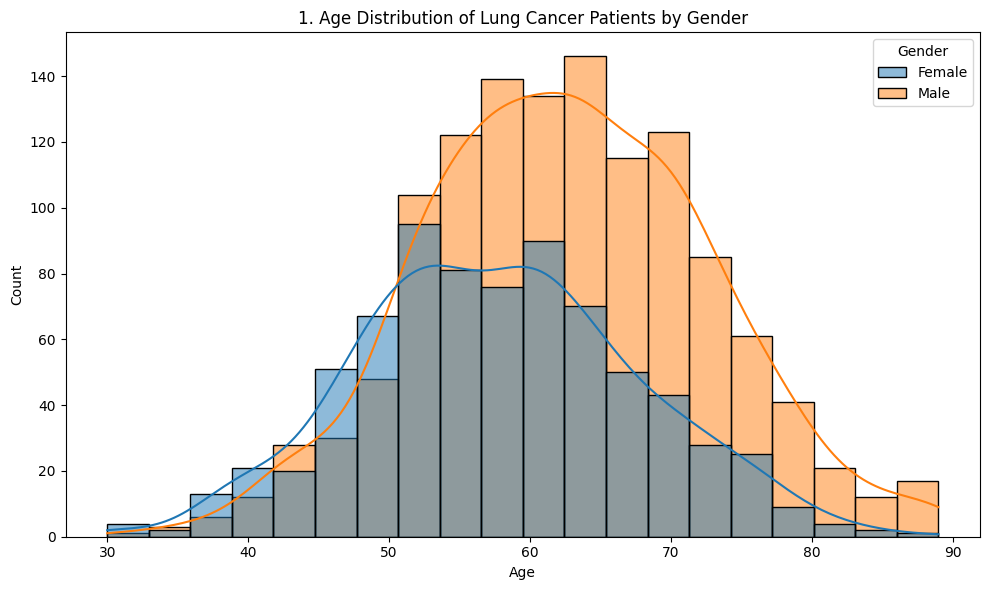

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Gender', kde=True, bins=20)
plt.title(f'{plot_no}. Age Distribution of Lung Cancer Patients by Gender')
show_fig()
plot_no += 1

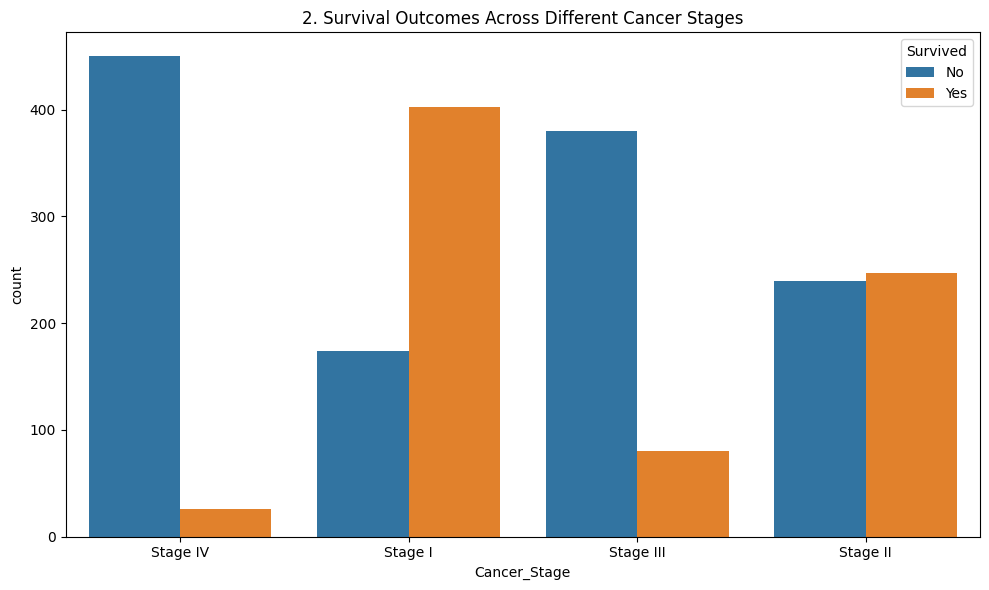

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Cancer_Stage', hue='Survived')
plt.title(f'{plot_no}. Survival Outcomes Across Different Cancer Stages')
show_fig()
plot_no += 1

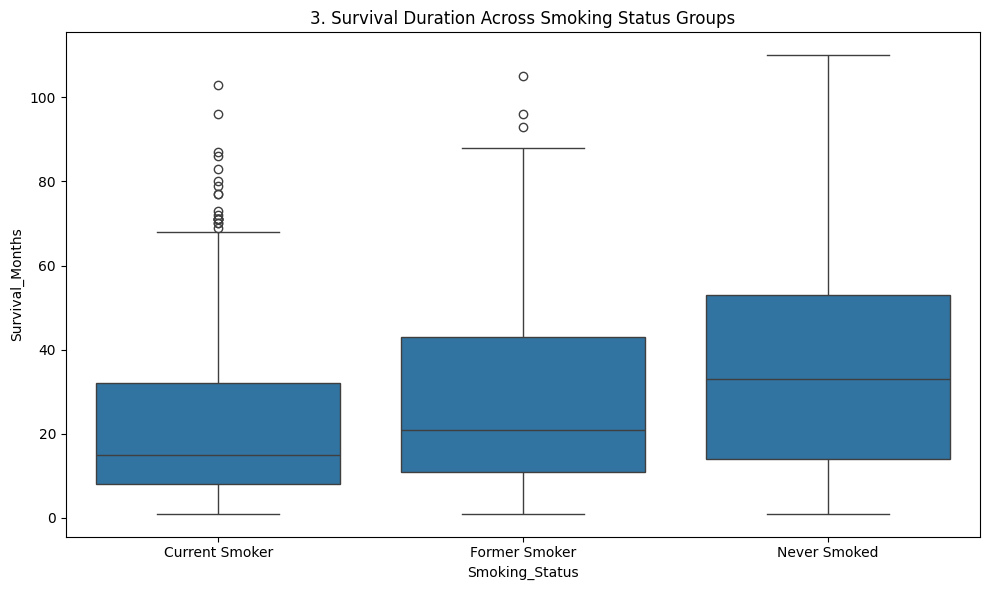

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Smoking_Status', y='Survival_Months')
plt.title(f'{plot_no}. Survival Duration Across Smoking Status Groups')
show_fig()
plot_no += 1

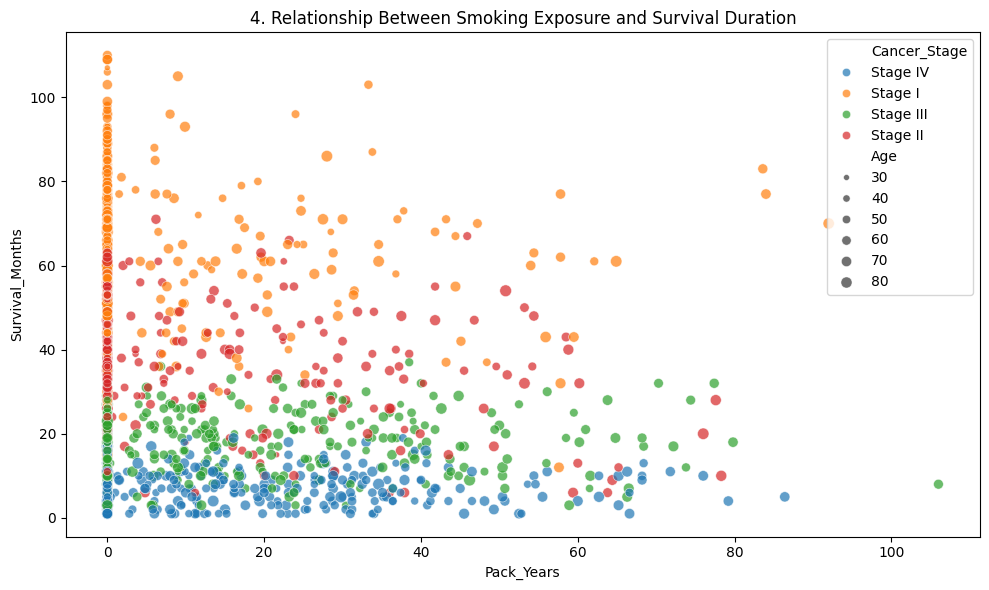

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Pack_Years', y='Survival_Months', hue='Cancer_Stage', size='Age', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Smoking Exposure and Survival Duration')
show_fig()
plot_no += 1

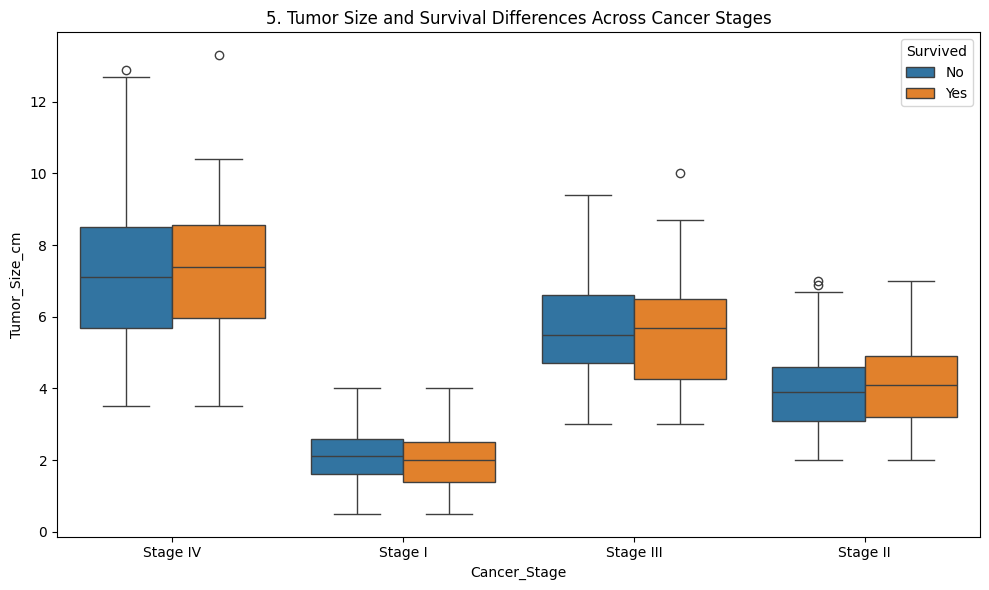

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Cancer_Stage', y='Tumor_Size_cm', hue='Survived')
plt.title(f'{plot_no}. Tumor Size and Survival Differences Across Cancer Stages')
show_fig()
plot_no += 1

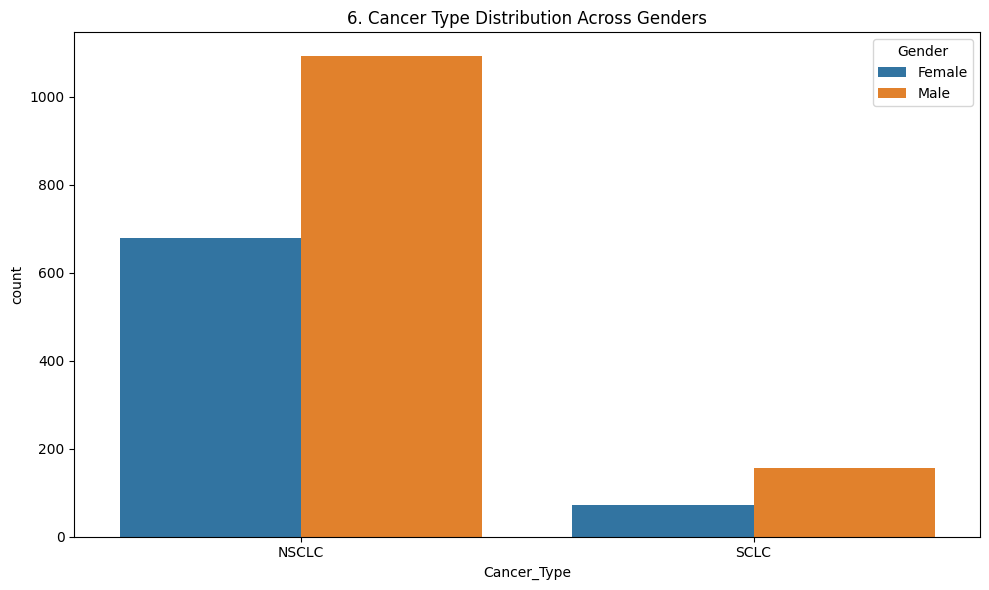

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Cancer_Type', hue='Gender')
plt.title(f'{plot_no}. Cancer Type Distribution Across Genders')
show_fig()
plot_no += 1

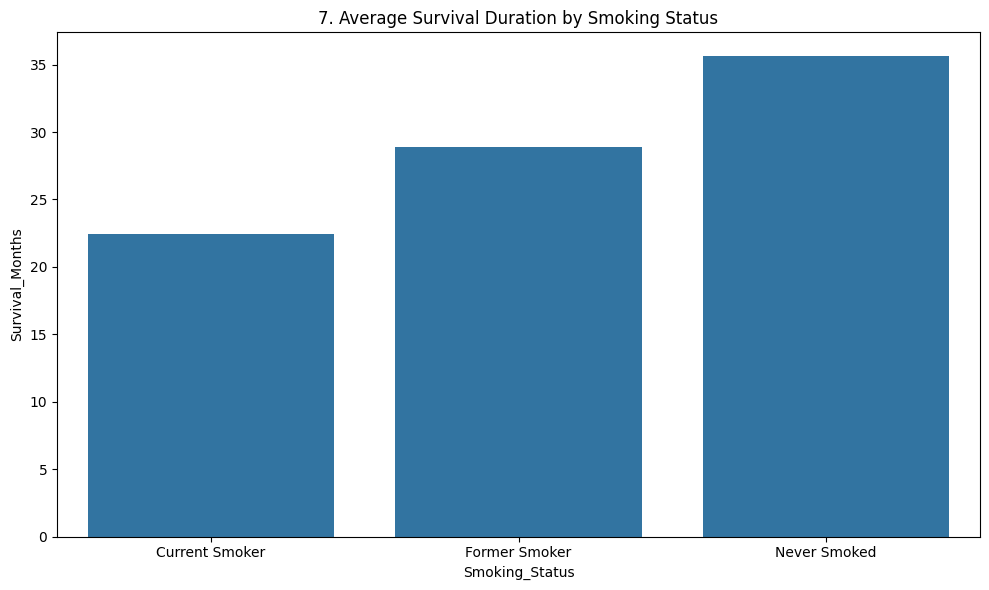

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Smoking_Status', y='Survival_Months', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Survival Duration by Smoking Status')
show_fig()
plot_no += 1

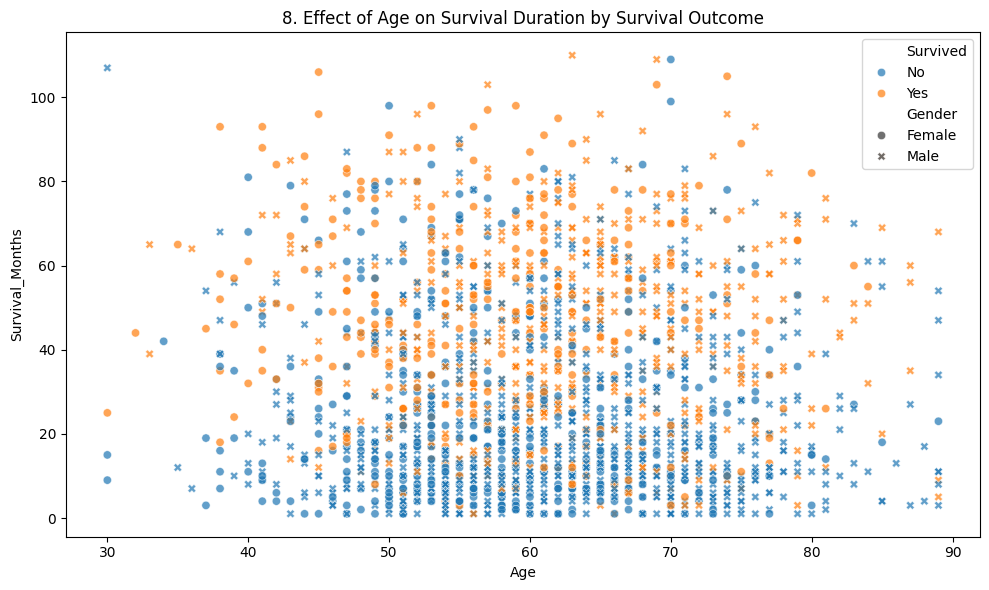

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Survival_Months', hue='Survived', style='Gender', alpha=0.7)
plt.title(f'{plot_no}. Effect of Age on Survival Duration by Survival Outcome')
show_fig()
plot_no += 1

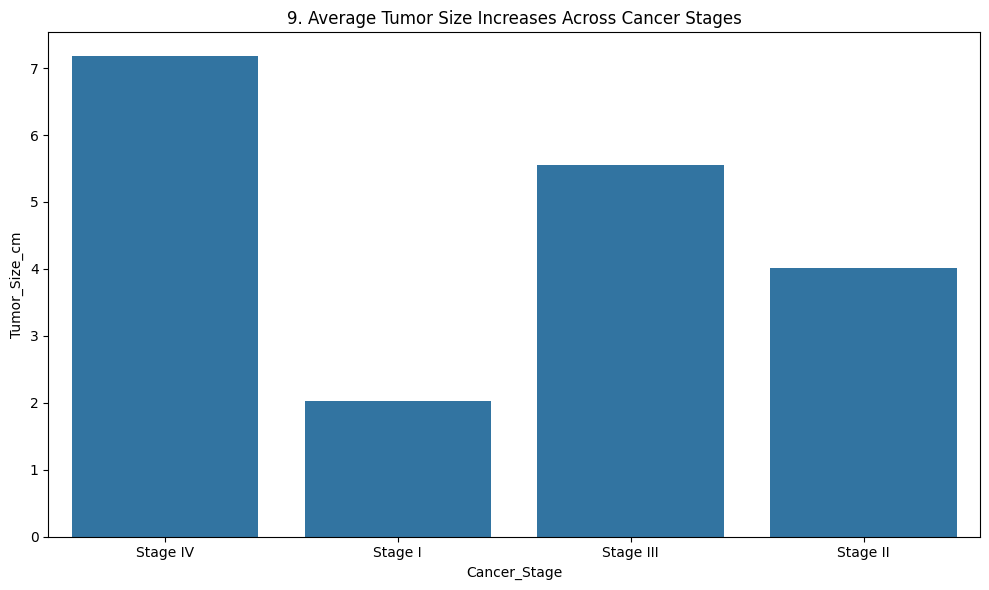

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Cancer_Stage', y='Tumor_Size_cm', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Tumor Size Increases Across Cancer Stages')
show_fig()
plot_no += 1

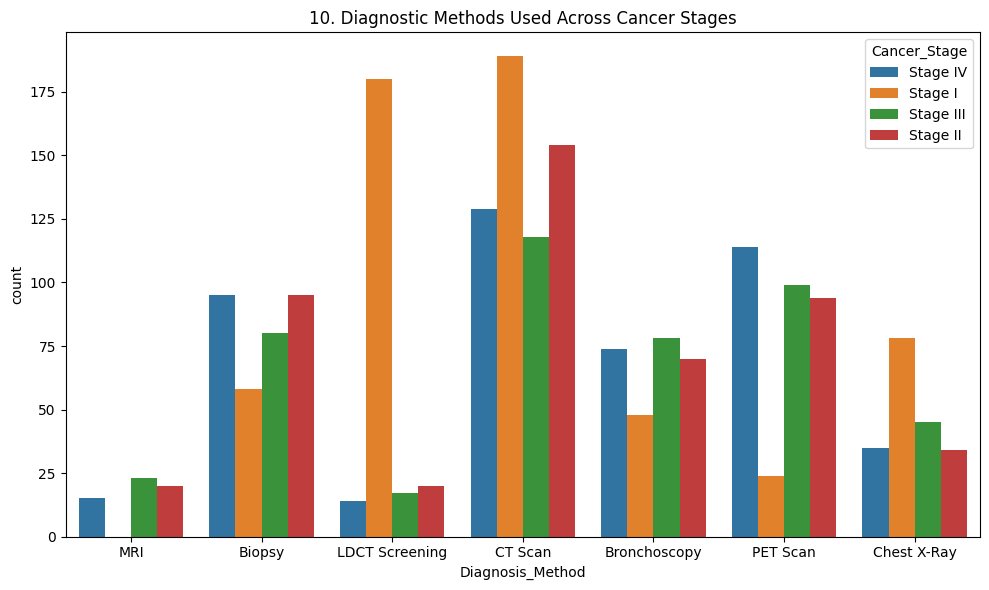

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Diagnosis_Method', hue='Cancer_Stage')
plt.title(f'{plot_no}. Diagnostic Methods Used Across Cancer Stages')
show_fig()
plot_no += 1

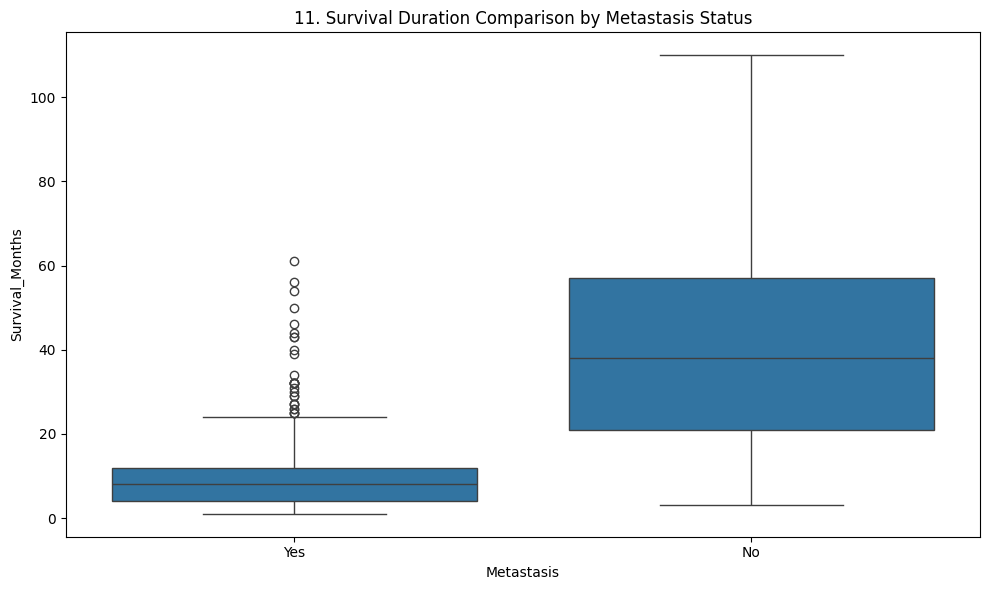

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Metastasis', y='Survival_Months')
plt.title(f'{plot_no}. Survival Duration Comparison by Metastasis Status')
show_fig()
plot_no += 1

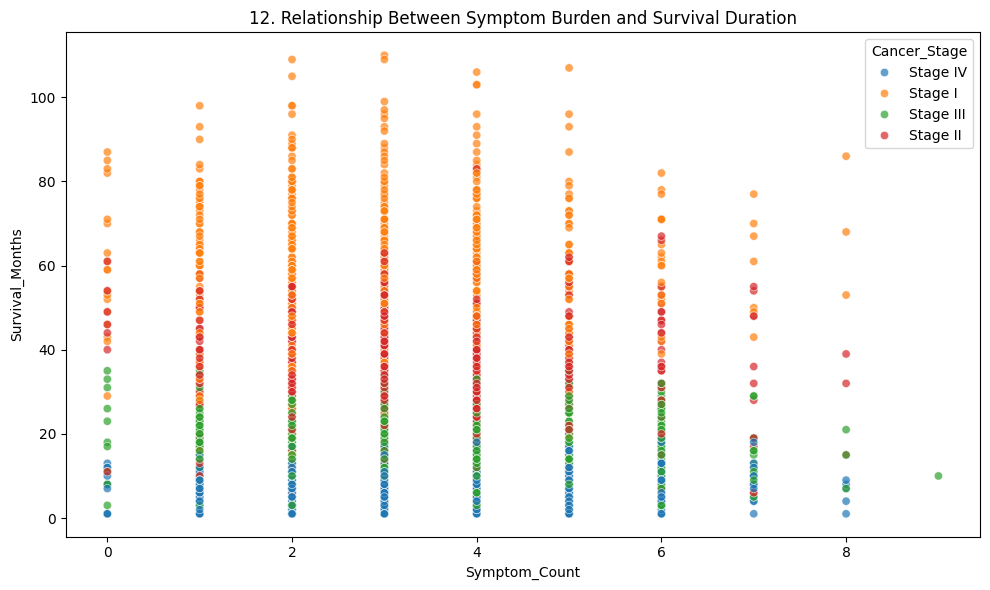

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Symptom_Count', y='Survival_Months', hue='Cancer_Stage', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Symptom Burden and Survival Duration')
show_fig()
plot_no += 1

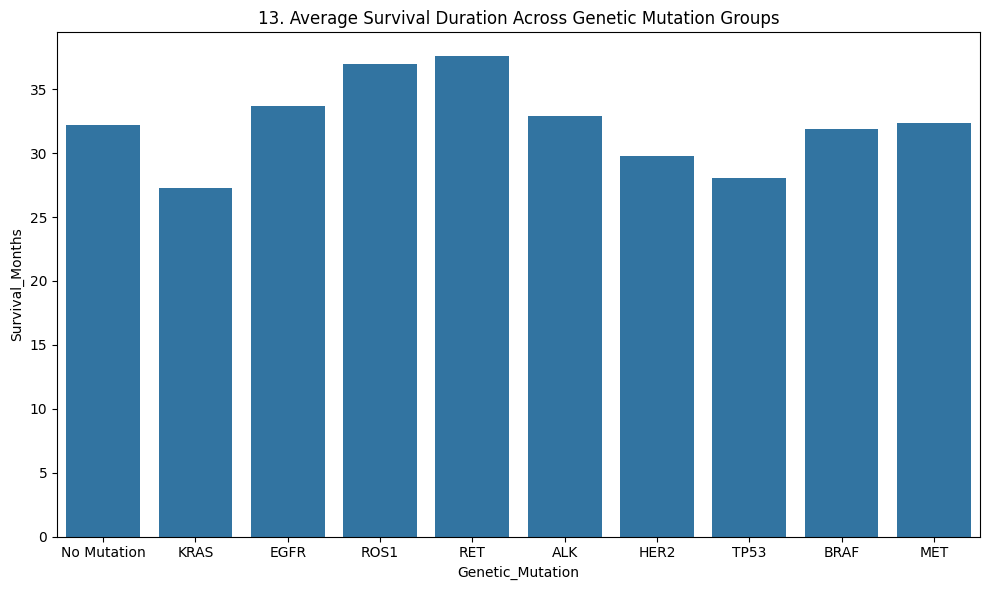

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Genetic_Mutation', y='Survival_Months', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Survival Duration Across Genetic Mutation Groups')
show_fig()
plot_no += 1

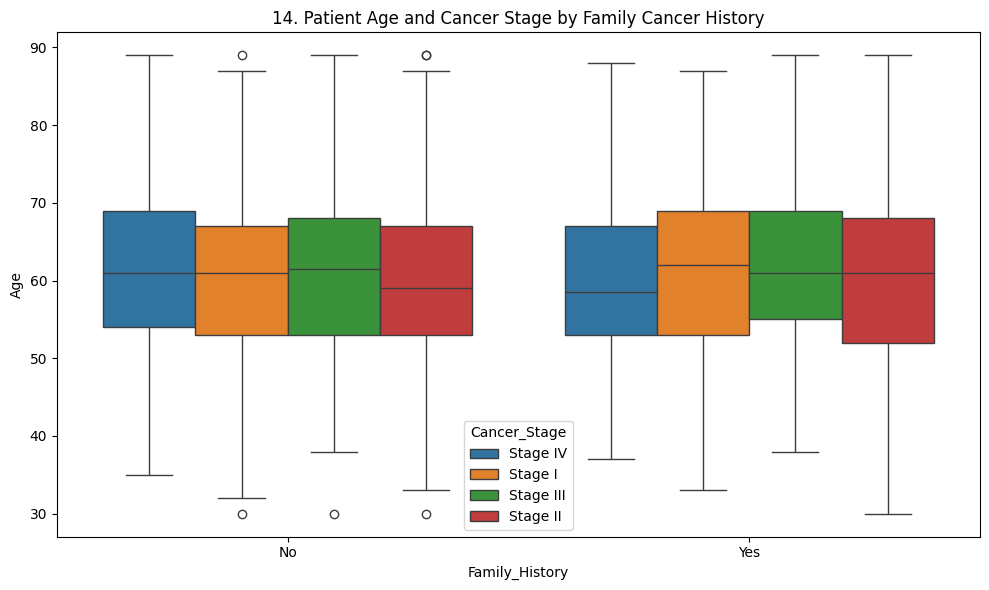

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Family_History', y='Age', hue='Cancer_Stage')
plt.title(f'{plot_no}. Patient Age and Cancer Stage by Family Cancer History')
show_fig()
plot_no += 1

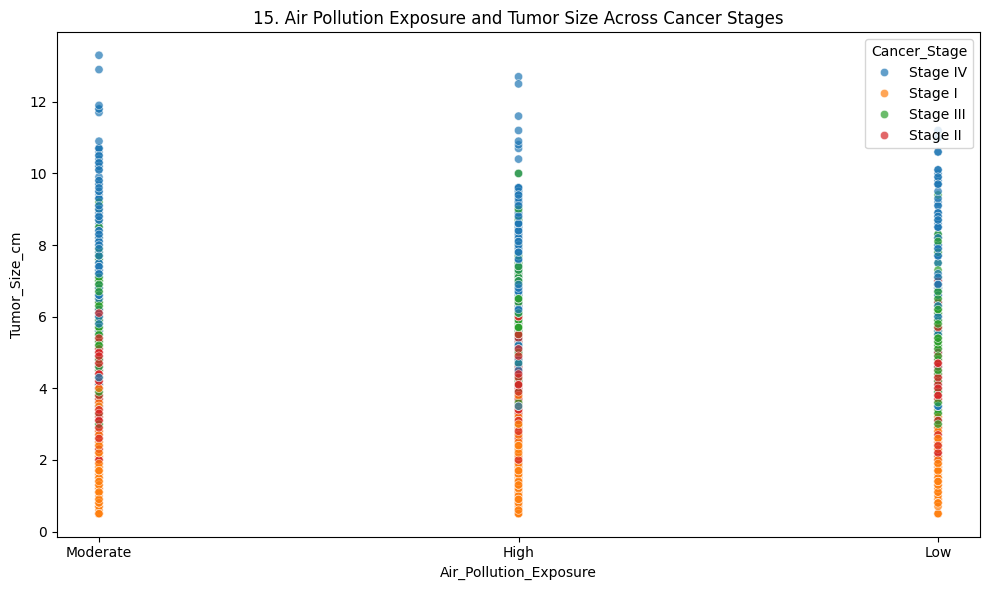

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Air_Pollution_Exposure', y='Tumor_Size_cm', hue='Cancer_Stage', alpha=0.7)
plt.title(f'{plot_no}. Air Pollution Exposure and Tumor Size Across Cancer Stages')
show_fig()
plot_no += 1

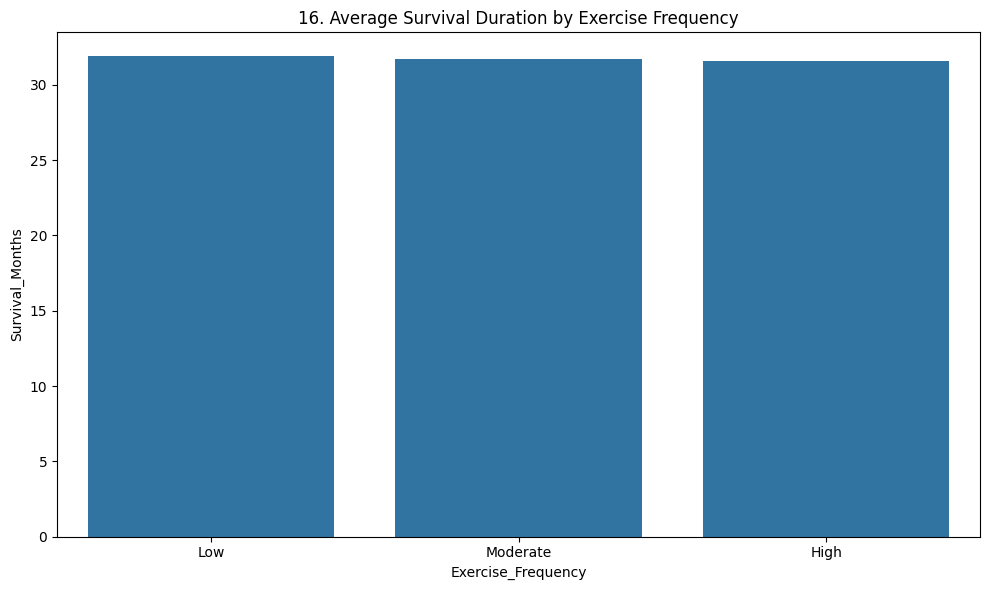

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Exercise_Frequency', y='Survival_Months', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Average Survival Duration by Exercise Frequency')
show_fig()
plot_no += 1

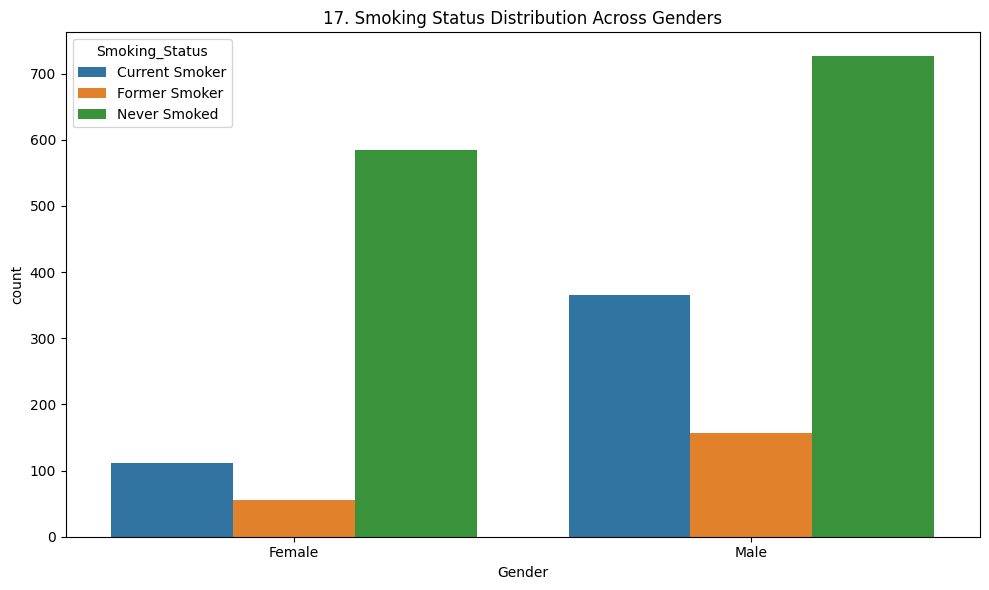

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Gender', hue='Smoking_Status')
plt.title(f'{plot_no}. Smoking Status Distribution Across Genders')
show_fig()
plot_no += 1

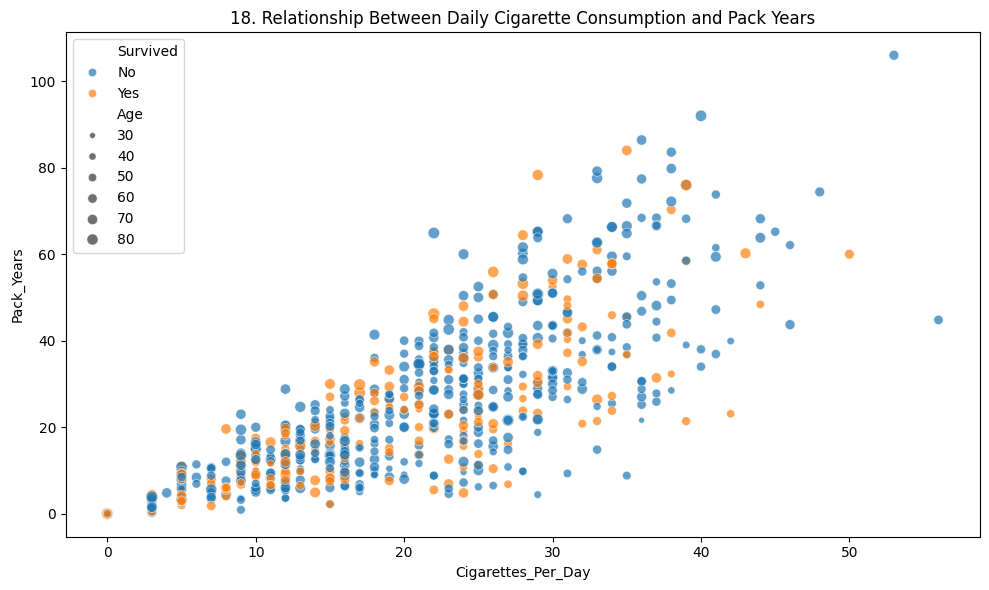

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Cigarettes_Per_Day', y='Pack_Years', hue='Survived', size='Age', alpha=0.7)
plt.title(f'{plot_no}. Relationship Between Daily Cigarette Consumption and Pack Years')
show_fig()
plot_no += 1

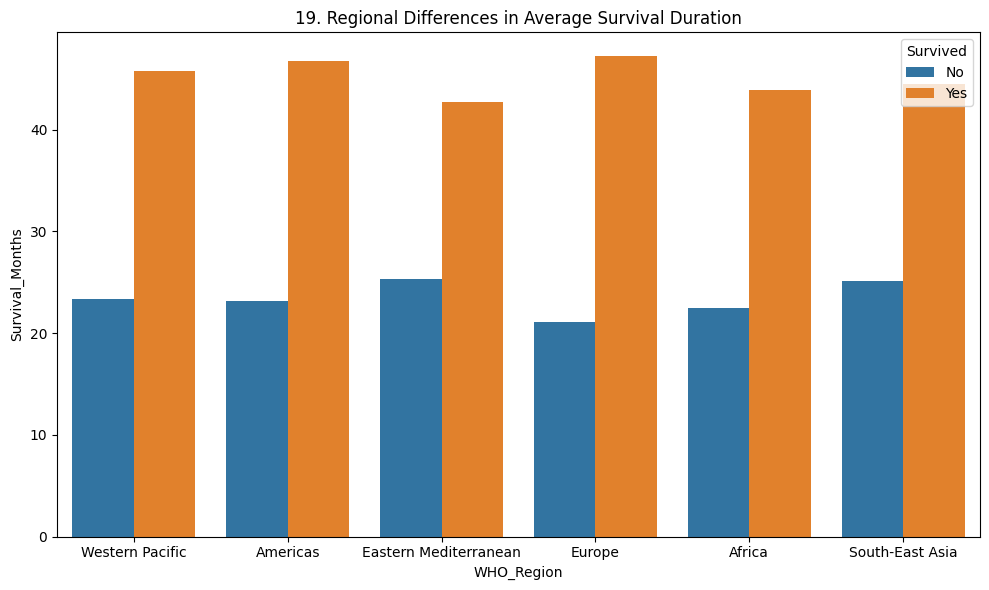

In [31]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='WHO_Region', y='Survival_Months', hue='Survived', estimator='mean', errorbar=None)
plt.title(f'{plot_no}. Regional Differences in Average Survival Duration')
show_fig()
plot_no += 1

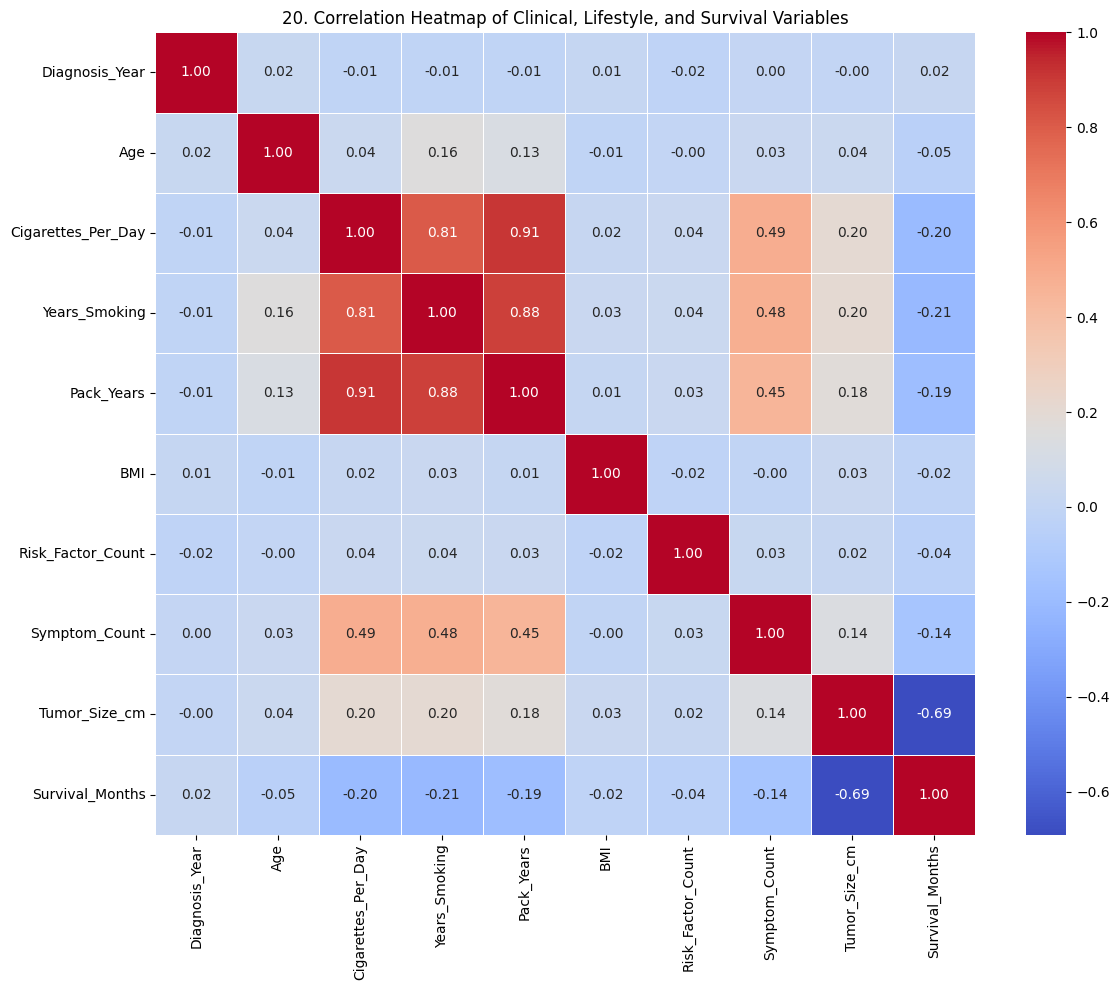

In [32]:
fig = plt.figure(figsize=(12,10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Clinical, Lifestyle, and Survival Variables')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [33]:
X = df.drop(columns=['Survival_Months', 'Patient_ID', 'Diagnosis_Date'], errors='ignore')
y = df['Survival_Months']

## Convert categorical columns into numeric values

In [34]:
X = pd.get_dummies(X, drop_first=True)

## Handle missing values

In [35]:
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

## Split the dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Scale the features

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Create the Gradient Boosting model

In [38]:
model = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

## Train the model

In [39]:
model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Make predictions

In [40]:
y_pred = model.predict(X_test)

## Evaluate the model

In [41]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"Accuracy-like Score: {r2 * 100:.2f}%")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.7215
Accuracy-like Score: 72.15%
MAE: 8.8037
RMSE: 11.8240


## Plot actual versus predicted values

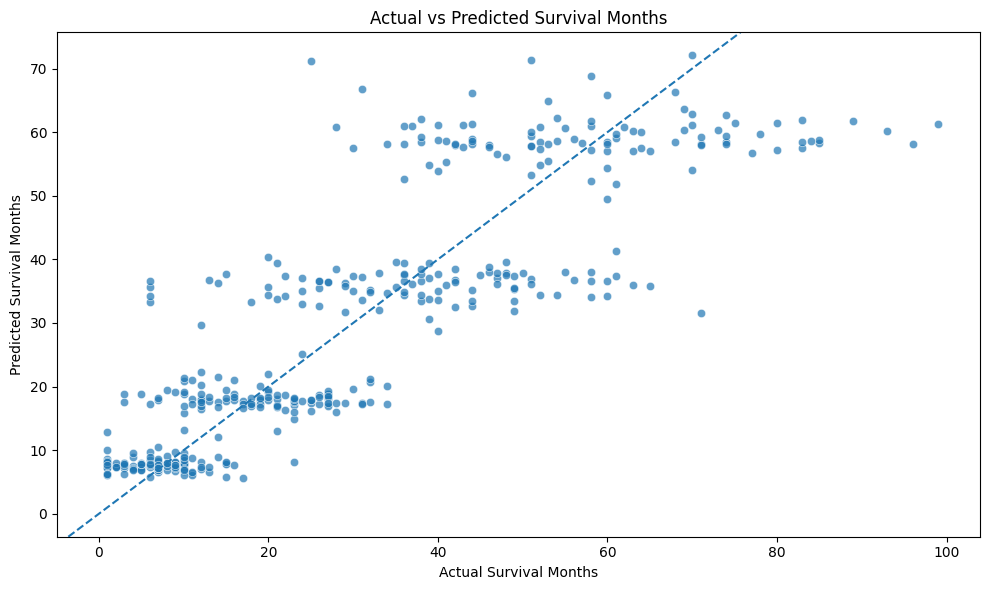

In [42]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel('Actual Survival Months')
plt.ylabel('Predicted Survival Months')
plt.title('Actual vs Predicted Survival Months')
plt.axline((0, 0), slope=1, linestyle='--')
show_fig()